# RQ2. ¿Qué activos protegen según el régimen macroeconómico?

## Pregunta e hipótesis

**Pregunta.** La correlación entre acciones y bonos, pilar de la cartera 60/40,
¿es estable o depende del régimen de inflación?

**H2 (formulada a priori):** la correlación entre acciones (SPY) y bonos largos
(TLT) cambia de signo según el régimen de inflación: positiva o cercana a cero
con inflación alta, negativa con inflación baja. Si es cierto, los bonos protegen
la cartera exactamente cuando la inflación es baja, y fallan como cobertura
cuando la inflación es el problema.

## Método

1. Retornos mensuales de SPY y TLT (muestra común desde 2002-08) y clases de
   activo defensivas (AGG, SHY, GLD).
2. Régimen de inflación: CPI interanual (`CPIAUCSL`, variación a 12 meses) por
   encima o debajo de la mediana muestral.
3. Contraste: diferencia de correlaciones entre regímenes con transformación z de
   Fisher y test normal de dos muestras.
4. Robustez: (a) régimen alternativo por dirección de tasas (FEDFUNDS vs 12 meses
   atrás); (b) rezago de 1 mes en el CPI para respetar su calendario de
   publicación; (c) subperiodos 2002-2014 y 2015-2026.

**Nota de diseño (sin look-ahead):** el CPI de un mes se publica a mediados del
mes siguiente. El análisis principal usa el CPI del mes concurrente por claridad
expositiva; la variante (b) repite el contraste con el último CPI ya publicado y
el resultado se mantiene.

In [1]:
import sys
from pathlib import Path

if str(Path.cwd().parent) not in sys.path:
    sys.path.insert(0, str(Path.cwd().parent))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

from src.db import get_engine

eng = get_engine()
monthly = pd.read_sql(
    "SELECT ticker, month_end, monthly_ret FROM v_monthly_returns", eng)
wide = monthly.pivot(index="month_end", columns="ticker", values="monthly_ret")
wide.index = pd.to_datetime(wide.index)

def macro_series(series_id):
    df = pd.read_sql(
        "SELECT date, value FROM fact_macro_value WHERE series_id = %(s)s ORDER BY date",
        eng, params={"s": series_id})
    df["date"] = pd.to_datetime(df["date"])
    return df.set_index("date")["value"]

cpi_yoy = macro_series("CPIAUCSL").pct_change(12).dropna()
fedfunds = macro_series("FEDFUNDS")

## Resultados

### Matriz de correlaciones del universo (retornos mensuales)

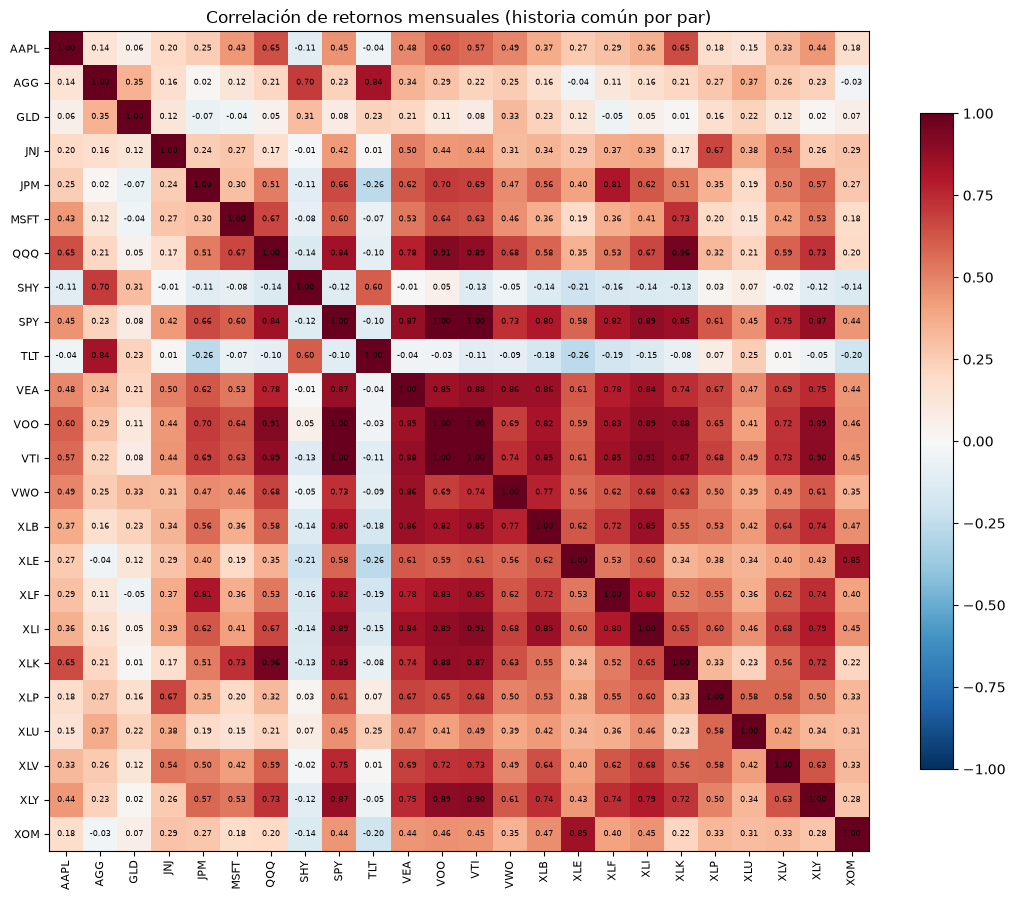

In [2]:
corr = wide.corr()
fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr)), corr.columns, rotation=90, fontsize=8)
ax.set_yticks(range(len(corr)), corr.index, fontsize=8)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=6)
plt.colorbar(im, shrink=0.8)
ax.set_title("Correlación de retornos mensuales (historia común por par)")
plt.tight_layout()
plt.show()

**Lectura.** Tres bloques claros: renta variable (acciones, sectores e
internacionales, correlaciones 0.5-0.9 entre sí), renta fija (TLT/AGG/SHY) con
correlación baja o negativa contra acciones, y oro (GLD) cerca de cero con casi
todo. La diversificación real está en cruzar bloques, no dentro de ellos.

### Correlación rolling SPY-TLT y régimen de inflación

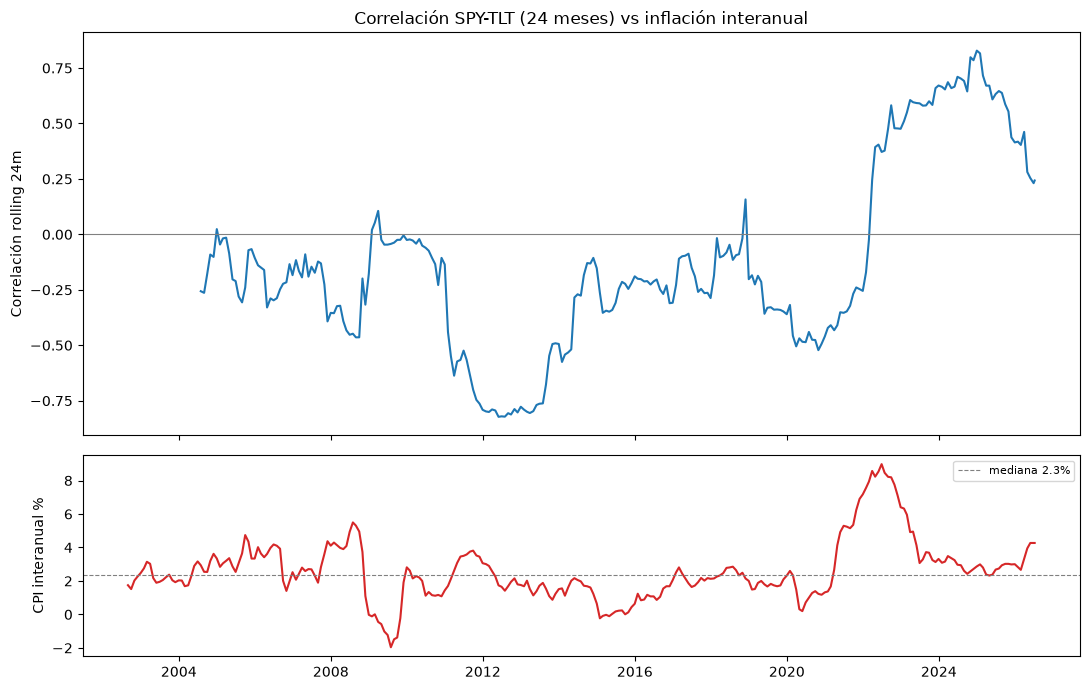

In [3]:
pair = wide[["SPY", "TLT"]].dropna()
infl = cpi_yoy.reindex(pair.index, method="ffill")
roll = pair["SPY"].rolling(24).corr(pair["TLT"])

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True,
                         gridspec_kw={"height_ratios": [2, 1]})
axes[0].plot(roll.index, roll, color="#1f77b4")
axes[0].axhline(0, color="gray", lw=0.8)
axes[0].set_ylabel("Correlación rolling 24m")
axes[0].set_title("Correlación SPY-TLT (24 meses) vs inflación interanual")
axes[1].plot(infl.index, infl * 100, color="#d62728")
axes[1].axhline(infl.median() * 100, color="gray", ls="--", lw=0.8,
                label=f"mediana {infl.median():.1%}")
axes[1].set_ylabel("CPI interanual %")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

### Contraste de H2

In [4]:
def fisher_test(sub_hi, sub_lo, a="SPY", b="TLT"):
    c_hi = sub_hi[a].corr(sub_hi[b])
    c_lo = sub_lo[a].corr(sub_lo[b])
    z = (np.arctanh(c_hi) - np.arctanh(c_lo)) / np.sqrt(
        1 / (len(sub_hi) - 3) + 1 / (len(sub_lo) - 3))
    p = 2 * (1 - stats.norm.cdf(abs(z)))
    return c_hi, c_lo, z, p

med = infl.median()
hi, lo = pair[infl > med], pair[infl <= med]
c_hi, c_lo, z, p = fisher_test(hi, lo)
print(f"Muestra: {pair.index.min().date()} a {pair.index.max().date()}, n = {len(pair)} meses")
print(f"Mediana de inflación: {med:.2%}")
print(f"Corr SPY-TLT con inflación ALTA: {c_hi:+.3f}  (n = {len(hi)})")
print(f"Corr SPY-TLT con inflación BAJA: {c_lo:+.3f}  (n = {len(lo)})")
print(f"Fisher z = {z:.2f}, p = {p:.4f}")

Muestra: 2002-08-30 a 2026-07-10, n = 288 meses
Mediana de inflación: 2.33%
Corr SPY-TLT con inflación ALTA: +0.088  (n = 144)
Corr SPY-TLT con inflación BAJA: -0.282  (n = 144)
Fisher z = 3.18, p = 0.0015


**Lectura.** Con inflación por encima de la mediana la correlación SPY-TLT es
+0.09; por debajo, -0.28. La diferencia es significativa (z = 3.18, p = 0.0015).
H2 se confirma en su parte esencial: los bonos largos diversifican con inflación
baja y dejan de hacerlo con inflación alta, justo cuando más se les necesita.

### ¿Qué protege en cada régimen?

In [5]:
rows = []
for tk in ["TLT", "AGG", "SHY", "GLD"]:
    sub = wide[["SPY", tk]].dropna()
    inf_t = cpi_yoy.reindex(sub.index, method="ffill")
    m_t = inf_t.median()
    ch, cl, z_t, p_t = fisher_test(sub[inf_t > m_t], sub[inf_t <= m_t], b=tk)
    rows.append({"activo": tk, "corr_infl_alta": ch, "corr_infl_baja": cl,
                 "z": z_t, "p": p_t})
pd.DataFrame(rows).set_index("activo").round(3)

,corr_infl_alta,corr_infl_baja,z,p
activo,,,,
TLT,0.088,-0.282,3.179,0.001
AGG,0.401,-0.002,3.488,0.000
SHY,-0.037,-0.232,1.673,0.094
GLD,0.177,-0.017,1.561,0.119


**Lectura.** El patrón se repite en toda la renta fija: la correlación con SPY
sube en inflación alta (AGG pasa de 0.00 a +0.40). Los bonos cortos (SHY) son
los que mejor conservan correlación no positiva en ambos regímenes. El oro
mantiene correlación baja en ambos, sin dirección clara: diversifica, pero no es
una cobertura fiable de acciones.

## Robustez

In [6]:
# (a) régimen por dirección de tasas
rising = (fedfunds - fedfunds.shift(12)).dropna() > 0
reg = rising.reindex(pair.index, method="ffill")
ch_a, cl_a, z_a, p_a = fisher_test(pair[reg], pair[~reg])
print(f"(a) Tasas subiendo vs bajando: {ch_a:+.3f} vs {cl_a:+.3f}  (z = {z_a:.2f}, p = {p_a:.4f})")

# (b) CPI con rezago de publicación de 1 mes
infl_lag = cpi_yoy.shift(1).reindex(pair.index, method="ffill")
m_l = infl_lag.median()
ch_b, cl_b, z_b, p_b = fisher_test(pair[infl_lag > m_l], pair[infl_lag <= m_l])
print(f"(b) CPI rezagado 1 mes:        {ch_b:+.3f} vs {cl_b:+.3f}  (z = {z_b:.2f}, p = {p_b:.4f})")

# (c) subperiodos
for name, sub in [("2002-2014", pair[pair.index < "2015"]),
                  ("2015-2026", pair[pair.index >= "2015"])]:
    inf_s = cpi_yoy.reindex(sub.index, method="ffill")
    m_s = inf_s.median()
    ch_c, cl_c, z_c, p_c = fisher_test(sub[inf_s > m_s], sub[inf_s <= m_s])
    print(f"(c) {name}:               {ch_c:+.3f} vs {cl_c:+.3f}  (z = {z_c:.2f}, p = {p_c:.4f})")

(a) Tasas subiendo vs bajando: +0.017 vs -0.196  (z = 1.81, p = 0.0708)
(b) CPI rezagado 1 mes:        +0.040 vs -0.247  (z = 2.45, p = 0.0141)
(c) 2002-2014:               -0.389 vs -0.256  (z = -0.89, p = 0.3736)
(c) 2015-2026:               +0.541 vs -0.353  (z = 5.62, p = 0.0000)


**Lectura de robustez.** El resultado sobrevive al rezago de publicación del CPI
(p = 0.014) y apunta en la misma dirección con el régimen de tasas (p = 0.07,
marginal). Los subperiodos revelan el matiz importante: entre 2002 y 2014 la
correlación fue negativa en ambos regímenes (inflación siempre baja y estable);
el cambio de signo lo produce la era 2015-2026, que contiene el episodio
inflacionario 2021-2023, donde la correlación con inflación alta saltó a +0.54.
La conclusión honesta: el régimen inflacionario importa, y el episodio reciente
es el que lo demuestra con fuerza; en décadas de inflación anclada la distinción
apenas se nota.

## Discusión y limitaciones

- Umbral de régimen por mediana muestral: simple y transparente, pero cualquier
  umbral discreto es una simplificación de un continuo.
- Las correlaciones por régimen mezclan meses no contiguos; la variante rolling
  del gráfico muestra la misma historia sin ese artificio.
- 288 meses en total; los subperiodos quedan con ~144, suficiente para Fisher
  pero no para umbrales más finos (terciles darían celdas muy pequeñas).
- Coherente con la evidencia publicada sobre correlación acciones-bonos y régimen
  inflacionario (Ilmanen 2003; Campbell, Pflueger y Viceira 2020).

## Conclusión ejecutiva

La correlación acciones-bonos no es una constante: es una función del régimen de
inflación. Con inflación baja, TLT fue el mejor diversificador de un portafolio
de acciones (correlación -0.28); con inflación alta, esa protección desapareció
(+0.09, y +0.54 en el episodio 2021-2023). Quien diseñe una cartera 60/40 debe
saber que su pilar defensivo se debilita precisamente en los años de inflación.
En esos regímenes, los bonos cortos conservaron mejor su papel diversificador y
el oro se mantuvo neutral. H2: confirmada, con el matiz de que el fenómeno lo
domina la era post-2015.

In [7]:
out = Path.cwd().parent / "docs" / "resultados"
out.mkdir(parents=True, exist_ok=True)
lines = [
    "# RQ2. Correlaciones por régimen macro",
    "",
    "**Hipótesis H2:** la correlación SPY-TLT cambia de signo según el régimen de inflación. **Veredicto: CONFIRMADA (con matiz temporal).**",
    "",
    f"- Corr SPY-TLT inflación alta: {c_hi:+.3f}; baja: {c_lo:+.3f} (Fisher z = {z:.2f}, p = {p:.4f}, n = {len(pair)} meses)",
    f"- Robustez: sobrevive al rezago de publicación del CPI (p = {p_b:.3f}); direccionalmente igual con régimen de tasas (p = {p_a:.3f})",
    "- Matiz: el cambio de signo lo domina 2015-2026 (episodio 2021-2023); en 2002-2014 la correlación fue negativa en ambos regímenes",
    "- AGG pierde su neutralidad en inflación alta (0.00 a +0.40); SHY es el que mejor conserva correlación no positiva; GLD neutral en ambos",
    "",
    "Caveats: umbral por mediana muestral; regímenes con meses no contiguos; 288 meses.",
]
(out / "rq2.md").write_text("\n".join(lines), encoding="utf-8")
print("escrito docs/resultados/rq2.md")

escrito docs/resultados/rq2.md
